Loading data... this might take a minute...

--- 3. Basic Inspection ---


,timestamp,grid_id,call_count,sms_count,internet_usage
0,NaT,datetime,0.0000,0.0000,0.0000
1,1970-01-01 00:00:00.001,2013-11-01 00:00:00,0.0273,0.3521,0.0000
2,1970-01-01 00:00:00.001,2013-11-01 00:00:00,0.0000,0.0000,0.0261
3,1970-01-01 00:00:00.001,2013-11-01 00:00:00,0.9939,2.8369,57.7729
4,1970-01-01 00:00:00.002,2013-11-01 00:00:00,0.0273,0.3581,0.0000



Data Types:
 timestamp         datetime64[ms]
grid_id                      str
call_count               float64
sms_count                float64
internet_usage           float64
dtype: object

Description:
                         timestamp    call_count     sms_count  internet_usage
count                     1891928  1.891929e+06  1.891929e+06    1.891929e+06
mean   1970-01-01 00:00:05.277000  3.075994e+00  3.926584e+00    4.359532e+01
min    1970-01-01 00:00:00.001000  0.000000e+00  0.000000e+00    0.000000e+00
25%    1970-01-01 00:00:03.153000  0.000000e+00  0.000000e+00    0.000000e+00
50%    1970-01-01 00:00:05.387000  1.180000e-02  0.000000e+00    0.000000e+00
75%    1970-01-01 00:00:07.492000  2.636000e-01  6.030000e-01    1.393000e-01
max           1970-01-01 00:00:10  2.013476e+03  1.606331e+03    2.777430e+04
std                           NaN  1.784517e+01  1.788137e+01    2.287623e+02

Missing Values:
 timestamp         1
grid_id           0
call_count        0
sms_count   

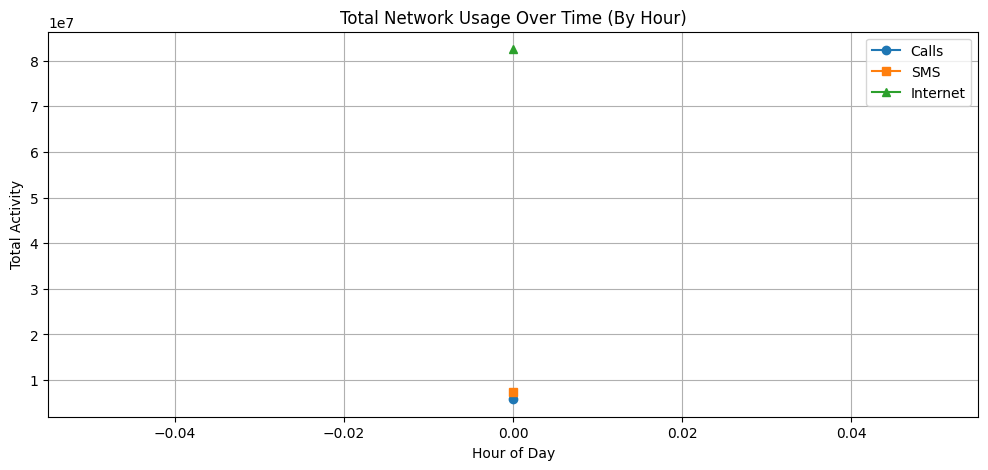

C:\Users\arya6\AppData\Local\Temp\ipykernel_20264\785713276.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_df.index, y=region_df.values, order=region_df.index, palette="viridis")


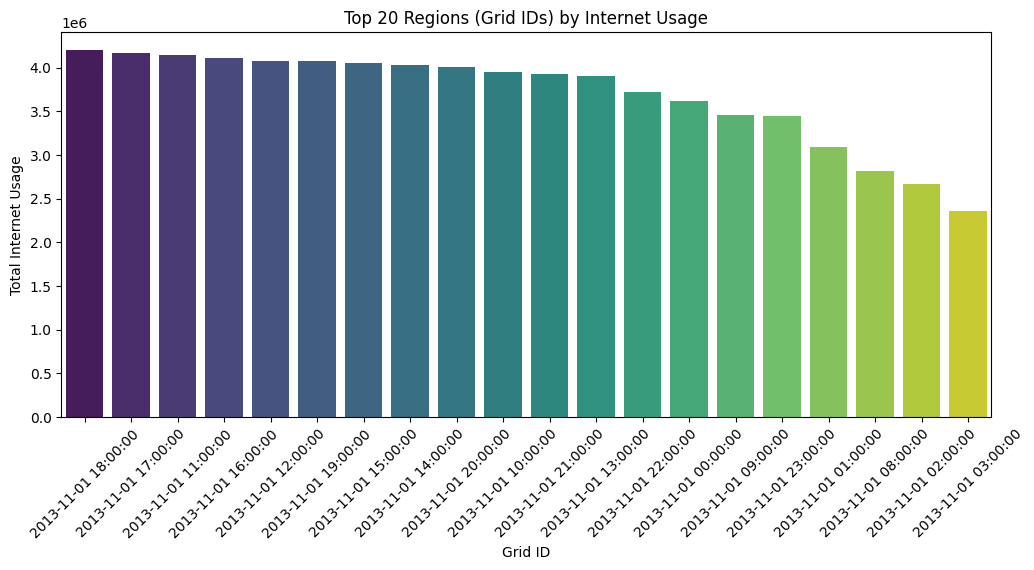

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the dataset using pandas
# Setting low_memory=False helps Pandas handle large files without DtypeWarnings
file_path = '../data/raw/sms-call-internet-mi-2013-11-01.csv'
columns = ['grid_id', 'timestamp', 'country_code', 'sms_in', 'sms_out', 'call_in', 'call_out', 'internet']

print("Loading data... this might take a minute...")
df = pd.read_csv(file_path, names=columns, low_memory=False)

# FIX: Force all usage columns to be numeric. 
# errors='coerce' turns any bad string data into NaN safely.
cols_to_convert = ['sms_in', 'sms_out', 'call_in', 'call_out', 'internet']
for col in cols_to_convert:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Now we can safely consolidate the usage columns 
df['call_count'] = df['call_in'].fillna(0) + df['call_out'].fillna(0)
df['sms_count'] = df['sms_in'].fillna(0) + df['sms_out'].fillna(0)
df['internet_usage'] = df['internet'].fillna(0)

# Keep only the required columns for inspection 
df = df[['timestamp', 'grid_id', 'call_count', 'sms_count', 'internet_usage']]

# Convert timestamp (Unix epoch milliseconds) to readable datetime
# We also force numeric here just in case the timestamp had string issues
df['timestamp'] = pd.to_numeric(df['timestamp'], errors='coerce')
df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')

print("\n--- 3. Basic Inspection ---")
# 3. Print df.head(), df.dtypes, df.describe(), df.isnull().sum() 
display(df.head())
print("\nData Types:\n", df.dtypes)
print("\nDescription:\n", df.describe())
print("\nMissing Values:\n", df.isnull().sum())

print("\n--- 4. Identify and Report ---")
# 4. Identify: missing timestamps, invalid/negative usage values, duplicate rows 
missing_timestamps = df['timestamp'].isnull().sum()
negative_calls = (df['call_count'] < 0).sum()
negative_sms = (df['sms_count'] < 0).sum()
negative_internet = (df['internet_usage'] < 0).sum()
duplicate_rows = df.duplicated().sum()

print(f"Missing Timestamps: {missing_timestamps}")
print(f"Negative/Invalid Usage Values: Calls({negative_calls}), SMS({negative_sms}), Internet({negative_internet})")
print(f"Duplicate Rows: {duplicate_rows}")

print("\n--- 5. Generating Charts ---")
# 5. Plot at least 2 charts 

# Chart 1: Usage over time
time_df = df.groupby(df['timestamp'].dt.hour)[['call_count', 'sms_count', 'internet_usage']].sum()

plt.figure(figsize=(12, 5))
plt.plot(time_df.index, time_df['call_count'], label='Calls', marker='o')
plt.plot(time_df.index, time_df['sms_count'], label='SMS', marker='s')
plt.plot(time_df.index, time_df['internet_usage'], label='Internet', marker='^')
plt.title('Total Network Usage Over Time (By Hour)')
plt.xlabel('Hour of Day')
plt.ylabel('Total Activity')
plt.legend()
plt.grid(True)
plt.show()

# Chart 2: Usage distribution per region (grid_id)
# Taking top 20 busiest grid_ids to keep the chart clean
region_df = df.groupby('grid_id')['internet_usage'].sum().sort_values(ascending=False).head(20)

plt.figure(figsize=(12, 5))
sns.barplot(x=region_df.index, y=region_df.values, order=region_df.index, palette="viridis")
plt.title('Top 20 Regions (Grid IDs) by Internet Usage')
plt.xlabel('Grid ID')
plt.ylabel('Total Internet Usage')
plt.xticks(rotation=45)
plt.show()